## IMPORT

In [1]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d, UnivariateSpline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from scipy.interpolate import UnivariateSpline
import copy
from pathlib import Path

%matplotlib inline

In [2]:
ROOT = Path.cwd().parent

data_path = ROOT / 'data'

## ANALYSIS

In [3]:
# Load the data
export_data = pd.read_csv(data_path / "dati_assoluti.csv")
export_data['Time'] = pd.to_datetime(export_data['Time'])

# Load the data
export_data_norm = pd.read_csv(data_path / "dati_normalizzati.csv")
export_data_norm['Time'] = pd.to_datetime(export_data['Time'])

In [4]:
def create_interactive_export_plot(export_data, title = " ", y_y = " "):
    countries = ["China", "Europe", "JP+KR", "SoutheastAsia", "Taiwan"]
    
    fig = go.Figure()

    for country in countries:
        country_data = export_data[country]
        fig.add_trace(go.Scatter(
            x=export_data["Time"],
            y=country_data,
            mode='lines+markers',
            name=country
        ))
    
    fig.update_layout(
        title=title,
        xaxis_title='Date',
        yaxis_title=y_y,
        width=1000,
        height=600,
        legend_title='Country',
        hovermode='x unified'
    )

    fig.show()

In [5]:
create_interactive_export_plot(export_data, title = "Export in $ in USA of PV", y_y = "Export in %")
create_interactive_export_plot(export_data_norm, title = "Market share of the Export of PV", y_y = "% Market Share")

### Polynomial

In [6]:
df = pd.read_csv(data_path / "dati_normalizzati.csv")

# Drop non-country columns
country_columns = df.columns.difference(['Time', 'total'])
market_shares = df[country_columns]

# Define utility computation
def compute_utility_functions(df_mk):
    # Sum all rows
    row_sum = df_mk.sum(axis=1)
    
    # Filter valid rows: all shares > 0 and total < 1
    valid_mask = (df_mk > 0).all(axis=1) & (row_sum < 1)
    df_valid = df_mk[valid_mask]

    # Compute utility
    utility = np.log(df_valid).subtract(np.log(1 - df_valid.sum(axis=1)), axis=0)
    return utility

utility = compute_utility_functions(market_shares)

In [7]:
# initialize time
t_years = np.linspace(1,20,215)

# define polynomial model
def polynomial_model(t, a, b, c):
    return a + b * t + c * t ** 2

# fit utility curves using polynomial model
head = 0
params_china, _ = curve_fit(polynomial_model, t_years, utility['China'][head:])
params_eu, _ = curve_fit(polynomial_model, t_years, utility['Europe'][head:])
params_jp_kr, _ = curve_fit(polynomial_model, t_years, utility['JP+KR'][head:])
params_sea, _ = curve_fit(polynomial_model, t_years, utility['SoutheastAsia'][head:])
params_taiw, _ = curve_fit(polynomial_model, t_years, utility['Taiwan'][head:])

In [8]:
# Generate predicted values
years_fit = np.linspace(utility.index[:].min(), utility.index[:].max(), 100)

# fitted curves points
utility_fit_pol = pd.DataFrame(np.transpose([polynomial_model(t_years, *params_china),
                            polynomial_model(t_years, *params_eu),
                            polynomial_model(t_years, *params_jp_kr),
                            polynomial_model(t_years, *params_sea),
                            polynomial_model(t_years, *params_taiw)]),
                           index=t_years,
                           columns = utility.columns
                          )

In [9]:
countries = ["China", "Europe", "JP+KR", "SoutheastAsia", "Taiwan"]

# Create the interactive Plotly figure
fig = go.Figure()

# Add raw data (scatter)
for country in countries:
    fig.add_trace(go.Scatter(
        x=t_years,
        y=utility[country],
        mode='markers',
        name=f'{country} (data)',
        marker=dict(symbol='circle')
    ))

# Add spline fits (smooth lines)
for country in countries:
    fig.add_trace(go.Scatter(
        x=t_years,
        y=utility_fit_pol[country],
        mode='lines',
        name=f'{country} (spline)',
        line=dict(dash='dash')  # You can customize line style here
    ))

# Layout
fig.update_layout(
    title='Utility Functions from Beer Firms Market Share (1963–2000)',
    xaxis_title='Year',
    yaxis_title='Utility',
    width=1000,
    height=500,
    legend_title='Country',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

In [10]:
### compute market share using solve_ivp
# compute change in utility function (i.e. g, the derivative over time of f (the utility function))
# to use it in the solve_ivp function the change is expressed as a function of t
def polynomial_derivative(t, params):
    return params[1] + 2 * params[2] * t

def LV_market_share(t, SPECIES, params_x, params_y, params_z, params_w, params_h):
    X, Y, Z, W, H = SPECIES

    gx = polynomial_derivative(t,params_x)
    gy = polynomial_derivative(t,params_y)
    gz = polynomial_derivative(t,params_z)
    gw = polynomial_derivative(t,params_w)
    gh = polynomial_derivative(t,params_h)
    
    dX_dt = X * (gx - gx * X - gy * Y - gz * Z - gw * W - gh*H)
    dY_dt = Y * (gy - gx * X - gy * Y - gz * Z - gw * W - gh*H)
    dZ_dt = Z * (gz - gx * X - gy * Y - gz * Z - gw * W - gh*H)
    dW_dt = W * (gz - gx * X - gy * Y - gz * Z - gw * W - gh*H)
    dH_dt = H * (gz - gx * X - gy * Y - gz * Z - gw * W - gh*H)

    return dX_dt, dY_dt, dZ_dt, dW_dt, dH_dt

In [11]:
## Initialize the time variable and y0
y0 = df[countries].iloc[0].tolist()
# add ten years for prediction
t_eval = np.linspace(0, 30, 360)
t_span = (min(t_eval), max(t_eval))

In [12]:
# solve the differential equation
X, Y, Z, W, H = solve_ivp(LV_market_share, t_span, y0, t_eval=t_eval, args=(params_china,params_eu,params_jp_kr,params_sea,params_taiw)).y

In [13]:
# plot results
results = [X, Y, Z, W, H]

# Define a consistent color for each country
color_map = {
    "China": "#1f77b4",        # Blue
    "Europe": "#ff7f0e",       # Orange
    "JP+KR": "#2ca02c",        # Green
    "SoutheastAsia": "#d62728",# Red
    "Taiwan": "#9467bd"        # Purple
}

fig = go.Figure()

for country in countries:
    fig.add_trace(go.Scatter(
        x=t_eval,
        y=market_shares[country],
        mode='lines',
        name=f'{country} (data)',
        line=dict(color=color_map[country], width=2)
    ))
for i, country in enumerate(countries):
    fig.add_trace(go.Scatter(
        x=t_eval,
        y=results[i],
        mode='lines',
        name=f'{country} (spline)',
        line=dict(color=color_map[country], dash='dash')
    ))

# Layout
fig.update_layout(
    title='Market Share of USA market',
    xaxis_title='Year',
    yaxis_title='Market Share %',
    width=1000,
    height=500,
    legend_title='Country',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()


### Splines

In [14]:
# Load dataset
df = pd.read_csv(data_path / "dati_normalizzati.csv")
# Extract market share columns
country_columns = df.columns.difference(["Time", "total"])
market_shares = df[country_columns]

In [15]:
# compute utility functions
def compute_utility_functions(df_mk):
    row_sum = df_mk.sum(axis=1)
    valid_mask = (df_mk > 0).all(axis=1) & (row_sum < 1)
    df_valid = df_mk[valid_mask]
    utility = np.log(df_valid).subtract(np.log(1 - df_valid.sum(axis=1)), axis=0)
    return utility

# utility functions
utility = compute_utility_functions(market_shares)

# Create a time vector aligned with utility data
t_years = np.linspace(1,20,215)

In [16]:
# Fit splines to utility values
splines = {
    reg: UnivariateSpline(t_years, utility[reg], s=5)
    for reg in utility.columns
}

# Compute derivatives of splines
derivatives = {
    reg: splines[reg].derivative()
    for reg in utility.columns
}

# Create fast interpolators from spline derivatives
dense_t = np.linspace(t_years.min(), t_years.max(), 1000)

deriv_interp = {
    reg: interp1d(dense_t, derivatives[reg](dense_t), kind='linear',
                  bounds_error=False, fill_value="extrapolate")
    for reg in utility.columns
}

In [17]:
# Here I compute the predicted values of the utility
predicted_utilities = {
    reg: splines[reg](dense_t)  # or any array of time points
    for reg in utility.columns
}

In [18]:
countries = ["China", "Europe", "JP+KR", "SoutheastAsia", "Taiwan"]

# Create the interactive Plotly figure
fig = go.Figure()

# Add scatter
for country in countries:
    fig.add_trace(go.Scatter(
        x=df["Time"],
        y=utility[country],
        mode='markers',
        name=f'{country} (data)',
        marker=dict(symbol='circle')
    ))

# Add spline fits
for country in countries:
    fig.add_trace(go.Scatter(
        x=df["Time"],
        y=predicted_utilities[country],
        mode='lines',
        name=f'{country} (spline)',
        line=dict(dash='dash')
    ))

# Layout
fig.update_layout(
    title='Utility Functions from Beer Firms Market Share (1963–2000)',
    xaxis_title='Year',
    yaxis_title='Utility',
    width=1000,
    height=500,
    legend_title='Country',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

In [19]:
# as above add differential equation utilities to differential equations

def LV_market_share(t, SPECIES, derivs):
    X, Y, Z, W, H = SPECIES
    gx = derivs["China"](t)
    gy = derivs["Europe"](t)
    gz = derivs["JP+KR"](t)
    gw = derivs["SoutheastAsia"](t)
    gh = derivs["Taiwan"](t)

    dX_dt = X * (gx - gx * X - gy * Y - gz * Z - gw * W - gh * H)
    dY_dt = Y * (gy - gx * X - gy * Y - gz * Z - gw * W - gh * H)
    dZ_dt = Z * (gz - gx * X - gy * Y - gz * Z - gw * W - gh * H)
    dW_dt = W * (gw - gx * X - gy * Y - gz * Z - gw * W - gh * H)
    dH_dt = H * (gh - gx * X - gy * Y - gz * Z - gw * W - gh * H)

    return [dX_dt, dY_dt, dZ_dt, dW_dt, dH_dt]


In [20]:
# solve the system

countries = ["China", "Europe", "JP+KR", "SoutheastAsia", "Taiwan"]
y0 = df[countries].iloc[0].tolist()
t_eval = np.linspace(1,20,240)
t_span = (min(t_eval), max(t_eval))

sol = solve_ivp(
    LV_market_share,
    t_span,
    y0,
    t_eval=t_eval,
    args=(deriv_interp,),
)

X, Y, Z, W, H = sol.y

In [21]:
results = [X, Y, Z, W, H]

# Plot results
color_map = {
    "China": "#1f77b4",        # Blue
    "Europe": "#ff7f0e",       # Orange
    "JP+KR": "#2ca02c",        # Green
    "SoutheastAsia": "#d62728",# Red
    "Taiwan": "#9467bd"        # Purple
}

fig = go.Figure()

for country in countries:
    fig.add_trace(go.Scatter(
        x=t_eval,
        y=market_shares[country],
        mode='lines',
        name=f'{country} (data)',
        line=dict(color=color_map[country], width=2)
    ))
for i, country in enumerate(countries):
    fig.add_trace(go.Scatter(
        x=t_eval,
        y=results[i],
        mode='lines',
        name=f'{country} (spline)',
        line=dict(color=color_map[country], dash='dash')
    ))

# Layout
fig.update_layout(
    title='Market Share of USA market',
    xaxis_title='Year',
    yaxis_title='Market Share %',
    width=1000,
    height=500,
    legend_title='Country',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

In [22]:
# forcast for next 10 years
countries = ["China", "Europe", "JP+KR", "SoutheastAsia", "Taiwan"]
y0 = df[countries].iloc[0].tolist()
t_eval = np.linspace(1, 30,360)
t_span = (min(t_eval), max(t_eval))

sol = solve_ivp(
    LV_market_share,
    t_span,
    y0,
    t_eval=t_eval,
    args=(deriv_interp,),
)

X, Y, Z, W, H = sol.y

In [23]:
results = [X, Y, Z, W, H]

color_map = {
    "China": "#1f77b4",        # Blue
    "Europe": "#ff7f0e",       # Orange
    "JP+KR": "#2ca02c",        # Green
    "SoutheastAsia": "#d62728",# Red
    "Taiwan": "#9467bd"        # Purple
}

fig = go.Figure()

for country in countries:
    fig.add_trace(go.Scatter(
        x=t_eval,
        y=market_shares[country],
        mode='lines',
        name=f'{country} (data)',
        line=dict(color=color_map[country], width=2)
    ))
for i, country in enumerate(countries):
    fig.add_trace(go.Scatter(
        x=t_eval,
        y=results[i],
        mode='lines',
        name=f'{country} (spline)',
        line=dict(color=color_map[country], dash='dash')
    ))

# Layout
fig.update_layout(
    title='Market Share of USA market',
    xaxis_title='Year',
    yaxis_title='Market Share %',
    width=1000,
    height=500,
    legend_title='Country',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

#### Tarrifs and some smoothness of the curve

In [24]:
# Load and preprocess data
df = pd.read_csv(data_path / "dati_normalizzati.csv")
df["Time"] = pd.to_datetime(df["Time"])

# Extract market shares
df["t_numeric"] = (df["Time"] - df["Time"].min()).dt.days / 365.25
country_columns = df.columns.difference(["Time", "total"])
market_shares = df[country_columns]

In [25]:
# Load data
df = pd.read_csv(data_path / "dati_normalizzati.csv")
df["Time"] = pd.to_datetime(df["Time"])
df["t_numeric"] = (df["Time"] - df["Time"].min()).dt.days / 365.25

# Define market share columns
countries = ["China", "Europe", "JP+KR", "SoutheastAsia", "Taiwan"]
market_shares = df[countries]

# Compute valid mask for utility calculation
row_sum = market_shares.sum(axis=1)
valid_mask = (market_shares > 0).all(axis=1) & (row_sum < 1)

# Compute utility from market shares
def compute_utility_functions(df_mk):
    row_sum = df_mk.sum(axis=1)
    utility = np.log(df_mk).subtract(np.log(1 - row_sum), axis=0)
    return utility

utility = compute_utility_functions(market_shares[valid_mask])
utility = utility.reset_index(drop=True)

# Filter time and compute numeric time vector
t_years = df.loc[valid_mask, "t_numeric"].reset_index(drop=True)

# Build tariff dummy DataFrame
df_tariffs = df.loc[valid_mask, ["Time"]].copy()
df_tariffs["China Tariff"] = (df_tariffs["Time"] >= "2012-05-01").astype(int)
df_tariffs["JP+KR Tariff"] = (df_tariffs["Time"] >= "2018-02-01").astype(int)
df_tariffs["SoutheastAsia Tariff"] = (df_tariffs["Time"] >= "2018-02-01").astype(int)
df_tariffs["Taiwan Tariff"] = (df_tariffs["Time"] >= "2014-12-01").astype(int)
df_tariffs["Europe Tariff"] = (df_tariffs["Time"] >= "2015-06-01").astype(int)
df_tariffs = df_tariffs.reset_index(drop=True)


In [26]:
# Define time cutoff
split_date = pd.to_datetime("2018-01-01")
train_mask = df_tariffs["Time"] < split_date

# Split data
t_train = t_years[train_mask]
utility_train = utility[train_mask].reset_index(drop=True)
tariffs_train = df_tariffs[train_mask].reset_index(drop=True)

t_test = t_years[~train_mask]
utility_test = utility[~train_mask].reset_index(drop=True)
tariffs_test = df_tariffs[~train_mask].reset_index(drop=True)


In [27]:
# Define smoothness values to test
s_grid = np.logspace(0, 2, 20)
cv = TimeSeriesSplit(n_splits=5)
best_s = {}
estimated_betas = {}

for country in countries:
    X_train = tariffs_train[[f"{country} Tariff"]].values.flatten()
    y_train = utility_train[country].values.flatten()
    t_train_vals = t_train.values

    # Estimate beta_j for the tariff dummy
    model = LinearRegression().fit(X_train.reshape(-1, 1), y_train.reshape(-1, 1))
    beta = model.coef_[0][0]
    estimated_betas[country] = beta

    # Remove tariff effect
    y_spline = y_train - beta * X_train

    # Cross-validate spline smoothness
    errors = {}
    for s_try in s_grid:
        cv_errors = []
        for train_idx, val_idx in cv.split(t_train_vals):
            t_cv_train, t_cv_val = t_train_vals[train_idx], t_train_vals[val_idx]
            y_cv_train, y_cv_val = y_spline[train_idx], y_spline[val_idx]

            spline = UnivariateSpline(t_cv_train, y_cv_train, s=s_try)
            y_pred = spline(t_cv_val)
            mse = mean_squared_error(y_cv_val, y_pred)
            cv_errors.append(mse)

        errors[s_try] = np.mean(cv_errors)

    best_s[country] = min(errors, key=errors.get)


In [28]:
# Containers
utility_spline_component = pd.DataFrame(index=utility_train.index)
splines = {}
derivatives = {}
predicted_utilities = {}
deriv_interp = {}

dense_t = np.linspace(t_years.min(), t_years.max(), 1000)

# Fit final model using best s per country
for country in countries:
    tariff_col = f"{country} Tariff"
    
    X_train = tariffs_train[[tariff_col]].values.flatten()
    y_train = utility_train[country].values.flatten()
    beta = estimated_betas[country]

    y_spline = y_train - beta * X_train
    s_best = best_s[country]

    spline = UnivariateSpline(t_train, y_spline, s=s_best)
    splines[country] = spline
    derivatives[country] = spline.derivative()
    utility_spline_component[country] = y_spline

    predicted_utilities[country] = spline(dense_t)
    deriv_interp[country] = interp1d(
        dense_t, derivatives[country](dense_t),
        kind="linear", bounds_error=False, fill_value="extrapolate"
    )


In [29]:
countries = ["China", "Europe", "JP+KR", "SoutheastAsia", "Taiwan"]

# Create the interactive Plotly figure
fig = go.Figure()

# Add scatter
for country in countries:
    fig.add_trace(go.Scatter(
        x=t_years,
        y=utility[country],
        mode='markers',
        name=f'{country} (data)',
        marker=dict(symbol='circle')
    ))

# Add spline fits
for country in countries:
    fig.add_trace(go.Scatter(
        x=t_years,
        y=predicted_utilities[country],
        mode='lines',
        name=f'{country} (spline)',
        line=dict(dash='dash')
    ))

# Layout
fig.update_layout(
    title='Utility Functions from Beer Firms Market Share (1963–2000)',
    xaxis_title='Year',
    yaxis_title='Utility',
    width=1000,
    height=500,
    legend_title='Country',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

In [30]:
# again add derivative to differential equations
def LV_market_share(t, SPECIES, derivs):
    X, Y, Z, W, H = SPECIES
    gx = derivs["China"](t)
    gy = derivs["Europe"](t)
    gz = derivs["JP+KR"](t)
    gw = derivs["SoutheastAsia"](t)
    gh = derivs["Taiwan"](t)

    dX_dt = X * (gx - gx * X - gy * Y - gz * Z - gw * W - gh * H)
    dY_dt = Y * (gy - gx * X - gy * Y - gz * Z - gw * W - gh * H)
    dZ_dt = Z * (gz - gx * X - gy * Y - gz * Z - gw * W - gh * H)
    dW_dt = W * (gw - gx * X - gy * Y - gz * Z - gw * W - gh * H)
    dH_dt = H * (gh - gx * X - gy * Y - gz * Z - gw * W - gh * H)

    return [dX_dt, dY_dt, dZ_dt, dW_dt, dH_dt]

# solve the system starting from initial condition
countries = ["China", "Europe", "JP+KR", "SoutheastAsia", "Taiwan"]
y0 = df[countries].iloc[0].tolist()
t_eval = np.linspace(0, 30, 360)
t_span = (min(t_eval), max(t_eval))

sol = solve_ivp(
    LV_market_share,
    t_span,
    y0,
    t_eval=t_eval,
    args=(deriv_interp,),
)

X, Y, Z, W, H = sol.y

In [31]:
results = [X, Y, Z, W, H]

In [32]:
import plotly.graph_objects as go

color_map = {
    "China": "#1f77b4",         # Blue
    "Europe": "#ff7f0e",        # Orange
    "JP+KR": "#2ca02c",         # Green
    "SoutheastAsia": "#d62728", # Red
    "Taiwan": "#9467bd"         # Purple
}

# Create Plotly figure
fig = go.Figure()

# Add scatter
for country in countries:
    fig.add_trace(go.Scatter(
        x=t_eval,
        y=market_shares[country],
        mode='lines',
        name=f'{country} (data)',
        line=dict(color=color_map[country], width=2)
    ))
# Add spline fits
for i, country in enumerate(countries):
    fig.add_trace(go.Scatter(
        x=t_eval,
        y=results[i],
        mode='lines',
        name=f'{country} (spline)',
        line=dict(color=color_map[country], dash='dash')
    ))

# Layout
fig.update_layout(
    title='Market Share of USA market',
    xaxis_title='Year',
    yaxis_title='Market Share %',
    width=1000,
    height=500,
    legend_title='Country',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()


In [33]:
# Clone the existing interpolators
deriv_interp_no_tariff = copy.deepcopy(deriv_interp)

# Replace the selected country's derivative with the pure spline derivative
country_no_tariff = "Europe"  
deriv_interp_no_tariff[country_no_tariff] = interp1d(
    dense_t,
    splines[country_no_tariff].derivative()(dense_t),
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate"
)

In [34]:
countries = ["China", "Europe", "JP+KR", "SoutheastAsia", "Taiwan"]
y0 = df[countries].iloc[0].tolist()
t_eval = np.linspace(0, 20, 240)
t_span = (min(t_eval), max(t_eval))

# solve the system
sol = solve_ivp(
    LV_market_share,
    t_span,
    y0,
    t_eval=t_eval,
    args=(deriv_interp_no_tariff,),
)

results_no_tarriff = sol.y

In [35]:
countries = ["China", "Europe", "JP+KR", "SoutheastAsia", "Taiwan"]

fig = go.Figure()

# Add original simulation
for i, country in enumerate(countries):
    fig.add_trace(go.Scatter(
        x=t_eval,
        y=results[i],
        mode='lines',
        name=f'{country} (with tariff)',
        line=dict(dash='dash')
    ))

# Add counterfactual simulation
for i, country in enumerate(countries):
    fig.add_trace(go.Scatter(
        x=t_eval,
        y=results_no_tarriff[i],
        mode='markers',
        name=f'{country} (no tariff)',
        marker=dict(symbol='circle')
    ))

fig.update_layout(
    title='Market Share of USA Market: Real vs No-Tariff Counterfactual',
    xaxis_title='Year',
    yaxis_title='Market Share',
    width=1000,
    height=500,
    legend_title='Country',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()


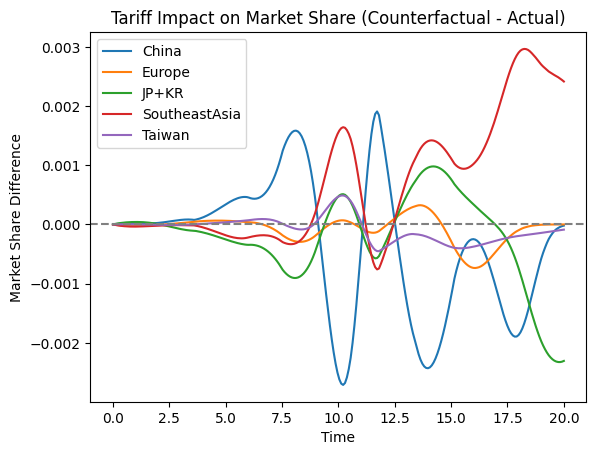

In [36]:
# plot
for i, country in enumerate(countries):
    plt.plot(t_eval,results_no_tarriff[i] - results[i][:240], label=country)
plt.axhline(0, color='gray', linestyle='--')
plt.title("Tariff Impact on Market Share (Counterfactual - Actual)")
plt.xlabel("Time")
plt.ylabel("Market Share Difference")
plt.legend()
plt.show()


In [37]:
# Clone the existing interpolators to create a no-tariff version
deriv_interp_no_tariff = copy.deepcopy(deriv_interp)

# Replace each country's derivative with its pure spline derivative (no tariff effect)
for country in countries:
    deriv_interp_no_tariff[country] = interp1d(
        dense_t,
        splines[country].derivative()(dense_t),
        kind="linear",
        bounds_error=False,
        fill_value="extrapolate"
    )


In [38]:
countries = ["China", "Europe", "JP+KR", "SoutheastAsia", "Taiwan"]
y0 = df[countries].iloc[0].tolist()
t_eval = np.linspace(0, 20, 240)
t_span = (min(t_eval), max(t_eval))

sol = solve_ivp(
    LV_market_share,
    t_span,
    y0,
    t_eval=t_eval,
    args=(deriv_interp_no_tariff,),
)

results_no_tarriff = sol.y

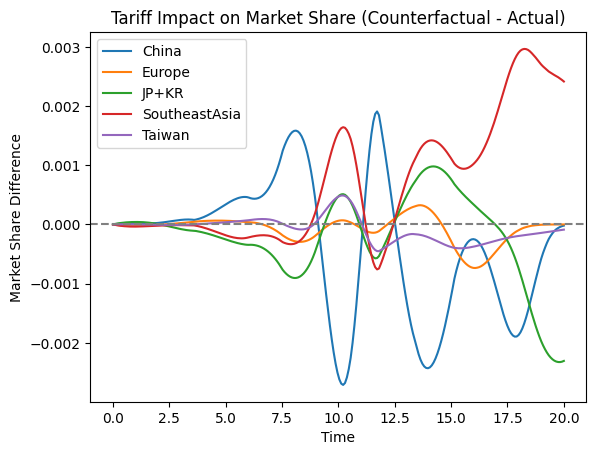

In [39]:
for i, country in enumerate(countries):
    plt.plot(t_eval,results_no_tarriff[i] - results[i][:240], label=country)
plt.axhline(0, color='gray', linestyle='--')
plt.title("Tariff Impact on Market Share (Counterfactual - Actual)")
plt.xlabel("Time")
plt.ylabel("Market Share Difference")
plt.legend()
plt.show()
